# Inputs for Cosmology block course exercises

TNG data specifications (contains information on fields and units):

https://www.tng-project.org/data/docs/specifications/#sec2a
https://www.tng-project.org/data/docs/background/

Check tutorial sheets of python, numpy, matplotlib and these links for guidance on plotting and manipulating data (indexing, typecasting, etc.):

Python: https://docs.python.org/3/tutorial/index.html

Plotting with matplotlib: https://matplotlib.org/stable/tutorials/pyplot.html

Numpy: https://numpy.org/doc/stable/user/quickstart.html

Online cosmological calculators:

https://colossus.astro.umd.edu/

https://www.astro.ucla.edu/%7Ewright/CosmoCalc.html

TNG links:

Units and description: https://www.tng-project.org/data/docs/specifications/

Backgroud information, cosmological parameters, boxsize: https://www.tng-project.org/data/docs/background/

# Write

In [ ]:
import numpy as np    #numpy for analysis
import matplotlib.pyplot as plt    #import plotting packages
import matplotlib as mpl
import h5py
from scipy.stats import binned_statistic_2d   #optional plotting package - can just use plt.hist2d
import illustris_python as il

**Code for reading halo data: (GroupMass,Group_R_Crit200, etc.)**

Use similar syntax for subhalo data: (SubhaloMass,SubhaloPos, etc.) by replacing 'Group' with 'Subhalo' and replacing the fields with the appropriate names

In [ ]:
basePath = '/home/tnguser/sims.TNG/TNG50-4-Dark/output'

snap = 99

nchunks = 4

fields = ['GroupMass','GroupPos']

data = {field: [] for field in fields}

for num in range(0,nchunks):    #number of file chunks

    with h5py.File(basePath+'/groups_%03d/fof_subhalo_tab_%03d.%s.hdf5'%(snap,snap,num),'r') as f:

        for field in fields:

            data[field].extend(np.array(f['Group'][field][:]))

Alternatively, you can use illustris_python to do it more elegantly (which is basically a Python wrapper for the same code as above) - see below

In [ ]:
basePath = '/home/tnguser/sims.TNG/TNG50-4-Dark/output'
snap = 99
fields = ['GroupMass','GroupPos']

#note that ‘data’ will just be an array (not a dictionary) if “fields” has only one element. It would be a dictionary if there are multiple fields
data = il.groupcat.loadHalos(basePath,snap,fields=fields)

**Code for reading particle data for the entire snapshot: (Coordinates, etc.)**

Different particle types and their respective fields can be found in the TNG website

In [ ]:
basePath = '/home/tnguser/sims.TNG/TNG50-4-Dark/output'

snap = 99    #change this to use different redshifts

nchunks = 4

fields = ['Coordinates']

data = {field: [] for field in fields}

for num in range(0,nchunks):    #number of file chunks

    with h5py.File(basePath+'/snapdir_%03d/snap_%03d.%s.hdf5'%(snap,snap,num),'r') as f:

        for field in fields:

            data[field].extend(np.array(f['PartType1'][field][:]))

Alternatively, you can use illustris_python to do it more elegantly (which is basically a Python wrapper for the same code as above) - see below

In [ ]:
basePath = '/home/tnguser/sims.TNG/TNG50-4-Dark/output'
snap = 99
fields = ['Coordinates']
partType = 1    #use 1 for dark matter
#note that 'data' will just be an array (not a dictionary) if “fields” has only one element. It would be a dictionary if there are multiple fields
data = il.snapshot.loadSubset(basePath,snap,partType=partType,fields=fields)
#the mass of dark matter particles are the same for each of them, and you can find them in https://www.tng-project.org/static/data/overview_tng_table.png

**Code for reading header data: (Info on Redshift, scale factor, etc.)**

In [ ]:
basePath = '/home/tnguser/sims.TNG/TNG50-4-Dark/output'
snap = 99
with h5py.File(basePath+'/groups_%03d/fof_subhalo_tab_%03d.%s.hdf5'%(snap,snap,0),'r') as f:

    header=(f['Header'])
    print(header.attrs.keys(),"\n")
    for key in header.attrs.keys():
        print(key,header.attrs[key])

Alternatively, you can use illustris_python to do it more elegantly (which is basically a Python wrapper for the same code as above) - see below

In [ ]:
header = il.groupcat.loadHeader(basePath,snap)

**Code for reading particle data for a specific halo:**

In [ ]:
basePath = '/home/tnguser/sims.TNG/TNG50-4-Dark/output'
partType = 1
dm_fields = ['Coordinates']
haloID = 0
snap = 99

Coordinates = il.snapshot.loadHalo(basePath,snap,haloID,partType,fields=dm_fields)

**Common bugs**

When encountering indexing issues, it's best to convert your lists or matrices to numpy arrays with

```
# data['fieldname'] = np.array(data['fieldname'])    #change fieldname to whatever you need
```
as numpy arrays can handle arithmetic and indexing easily.. (usually at least)


**Function to make scatter plots**

What do you think x_axis and y_axis should be?

In [ ]:
#use this for making scatter plots of haloes and dark matter particles
plt.scatter(x=x_axis,y=y_axis,s=size)    #note that x_axis,y_axis,size need to be defined by YOU

**Function to make 2D histograms**

What do you think x_axis, y_axis, weights and nbins should be?

In [ ]:
#use this for making a 2D histogram of dark matter particles
plt.hist2d(x=x_axis,y=y_axis,weights=weights,bins=nbins,norm=mpl.colors.LogNorm()) #see https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.hist2d.html
#you can alternatively also use scipy.stats.binned_statistic_2d

**Function to make conditions for arrays, modify as needed**

In [ ]:
np.where((array>low) & (array<high))

# Problem Sheet 2

First, we need the equations - write them down!

With the equations in hand, we can now create simple functions for estimating the Hubble factor & density parameters as a function of redshift. But what about for distances and time vs redshift? We need a way to integrate numerically!

Where to start? https://docs.scipy.org/doc/scipy/reference/generated/scipy.integrate.quad.html

In [ ]:
from scipy import integrate as si
import numpy as np

<font size=3> Let's try and calculate the definite integral of $$\mathrm{\int_{0}^{4} x^2\,dx}$$

In [ ]:
func = lambda x: x**2    #this is the syntax for writing a "lambda function" - reproduce this as needed for the exercises!
#this is the syntax for numerical integration for scipy.integrate.quad (https://docs.scipy.org/doc/scipy/reference/generated/scipy.integrate.quad.html)
print(si.quad(func, 0, 4))    #numerical result - 0,4 are the lower and upper bounds for this definite integral
print(4**3 / 3.)  # analytical result

(21.333333333333336, 2.368475785867001e-13)
21.333333333333332


Note that 'func' is a function of x, and when integrating with si.quad, func is the integrand, while the differential $dx$ is already taken care of internally

<font size=3> Let's try and calculate the definite integral of $$\mathrm{\int_{0}^{\infty} e^{-x}\,dx}$$

In [ ]:
func = lambda x: np.exp(-x)    #this is the syntax for writing a "lambda function" - reproduce this as needed for the exercises!
print(si.quad(func,0,np.inf))    #numerical result
print(1)    #analytical result

(1.0000000000000002, 5.842606742906004e-11)
1


<font size=3> Let's try and calculate the definite integral of $$\mathrm{\int_{0}^{5} \frac{a}{b}x\,dx}$$

In [ ]:
func = lambda x,a,b: a/b*x
print(si.quad(func,0,5,args=(1,2)))    #this is the syntax for integrating with arguments - reproduce this as needed for the exercises!

(6.25, 6.938893903907228e-14)


Use a large range of redshift from [$10^{-4}-10^4$] by defining an array of redshift values **in log space** as

```
z = np.logspace(-4, 4, 100)
```
np.logspace return numbers spaced evenly on a log scale. see https://numpy.org/doc/2.0/reference/generated/numpy.logspace.html for more info

Then, compute all required quantities such as $H(z),E(z),\Omega_X(z),t(z)$ and so on for each of these z values.

For context, $z=0$ corresponds to the Universe today, while $z=\infty$ is the Big Bang


Save cosmological parameters you need as dictionaries. For example, for a $\Lambda$CDM Universe, the cosmology can be defined as

```
LCDM_dict = {'Omega_m0': 0.315, 'Omega_l0':0.685,'k':0, 'Omega_r0': 9.23e-5,'Omega_b0':0.047, 'H_0':67.3,'sigma_8':0.829,'n_s':0.965}
```

You can then call these values when needed by using LCDM_dict['param'] where 'param' is the cosmological parameter you want.

How would these values change for Einstein-de Sitter and de Sitter Universes? Save them as separate dictionaries.

With these inputs, you are now ready to tackle Problem 2. Make figures with clear colors and labels, with units mentioned. Good luck!

In [ ]:
def myfunc(z,a,b):    #example of a function
  output = z*a/b
  return ouptut

# Problem Sheet 3

Inputs for questions 1,2

In [ ]:
#use the header to get useful information or particular snapshots

header = il.groupcat.loadHeader(basePath,snap)
a = header['Time']    #scale factor
redshift = header['Redshift']    #Redshift

You will need the scale factor to convert from comoving coordinates to physical coordinates when loading a snapshot at $z>0$. As a reminder,

$d_{\rm physical}\,=\,d_{\rm comoving}\times a\,=d_{\rm comoving}\times \frac{1}{1+z}$

i.e., physical distances will be smaller at higher redshifts (earlier in the Universe, when it was smaller)

Once you have converted from $ckpc/h$ to physical units, i.e., $kpc$, you can make 3 dimensional bins using the scipy binned_statistic_dd package (see https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.binned_statistic_dd.html#scipy.stats.binned_statistic_dd)

Evaluate volume densities using the DM masses and thereby also overdensities.

In [ ]:
from scipy.stats import binned_statistic_dd

#set Coordinates and n_bins yourself - what would they be?
bincounts = binned_statistic_dd(Coordinates,np.arange(len(Coordinates)),bins=n_bins,statistic='count')    #bincounts[0] will be a 3D array

To make the histogram of log(1+$\delta$), flatten the output array from binned_statistic_dd using bincounts[0].flatten() - this will rearrange your 3D array into a 1D array so you can plot counts (or PDF) vs log(1+$\delta$) easily.

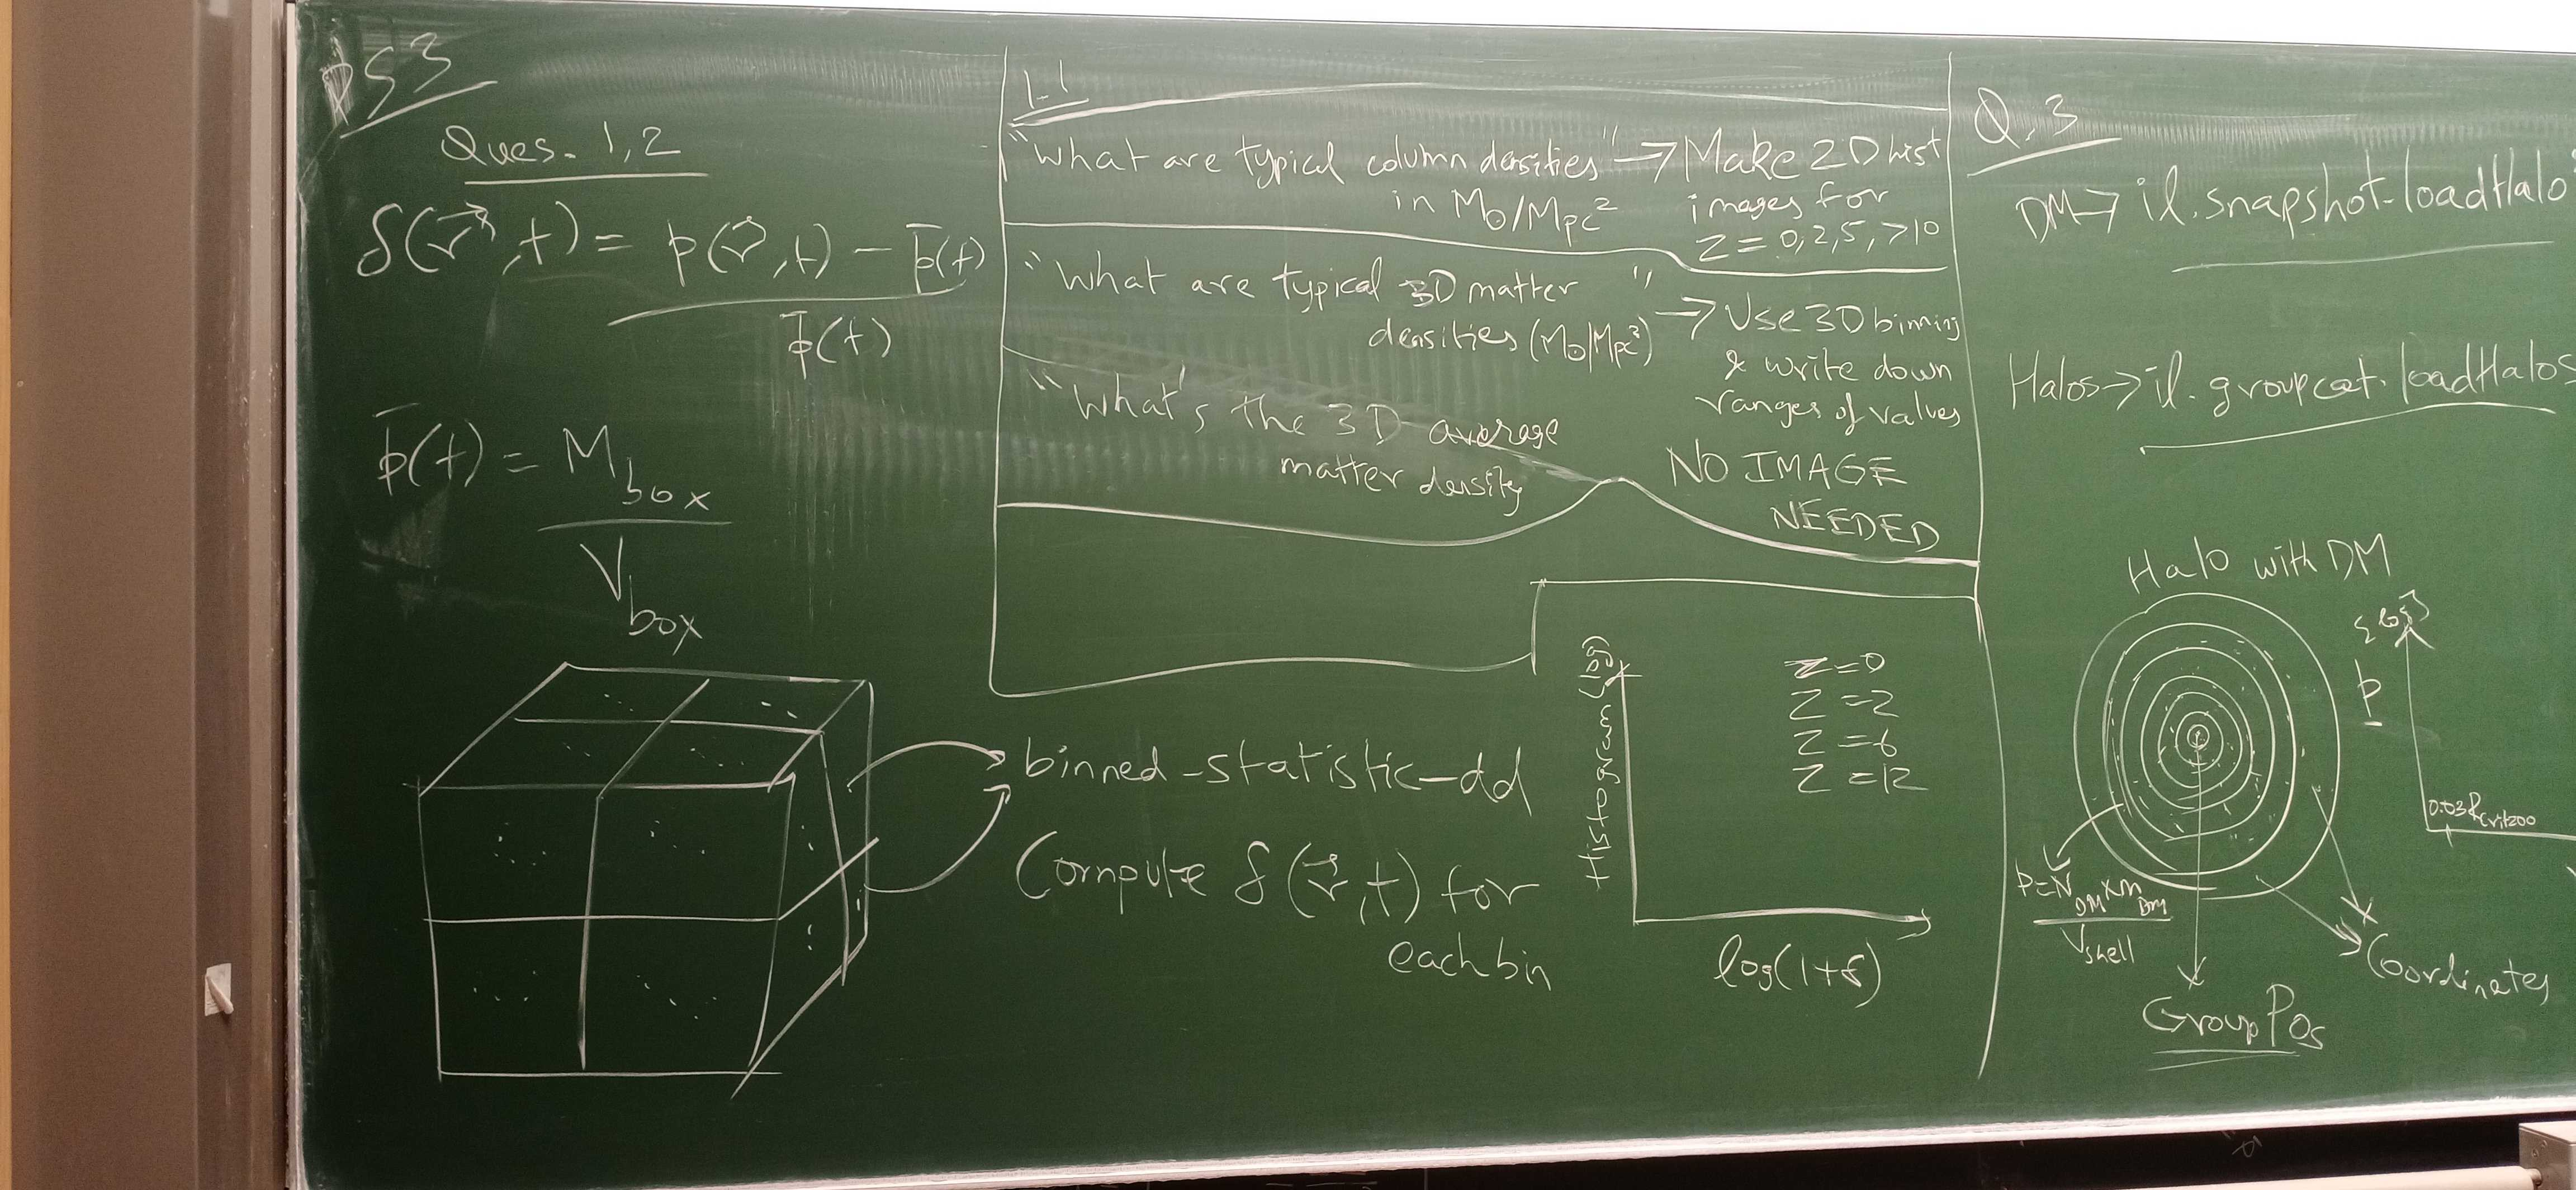

Inputs for question 3

General tips:

* Define a function to compute distances to dark matter particles from the center of a halo (i.e., GroupPos), taking Coordinates, GroupPos, BoxSize as arguments  
*   Make plots for one halo first, then for multiple halos
*  Use the data I/O codes from earlier to load particle coordinates, halo mass, position, Rcrit200, Mcrit200
* If data takes too long to plot,bin (loading should be fast though!), use downsampling to only plot parts of your data. You can achieve this by for e.g. using
* Note that downsampling is only part of the solution for optimizing your code - try different downsampling sizes for various spatial scales as the histogram of overdensities may be clear even for severe downsampling in some cases


```
n_downsample = 100    #pick a value that you want
Coordinates = il.snapshot.loadSubset(basePath, snapNum, 1,fields=['Coordinates'])
new_coordinates = Coordinates[::n_downsample]    #downsampled coordinates
```

Note that the weights for plt.hist2d will have to be rescaled upwards accordingly by n_downsample to compensate for the lack of particles
i.e., weights = Masses*n_downsample/Area

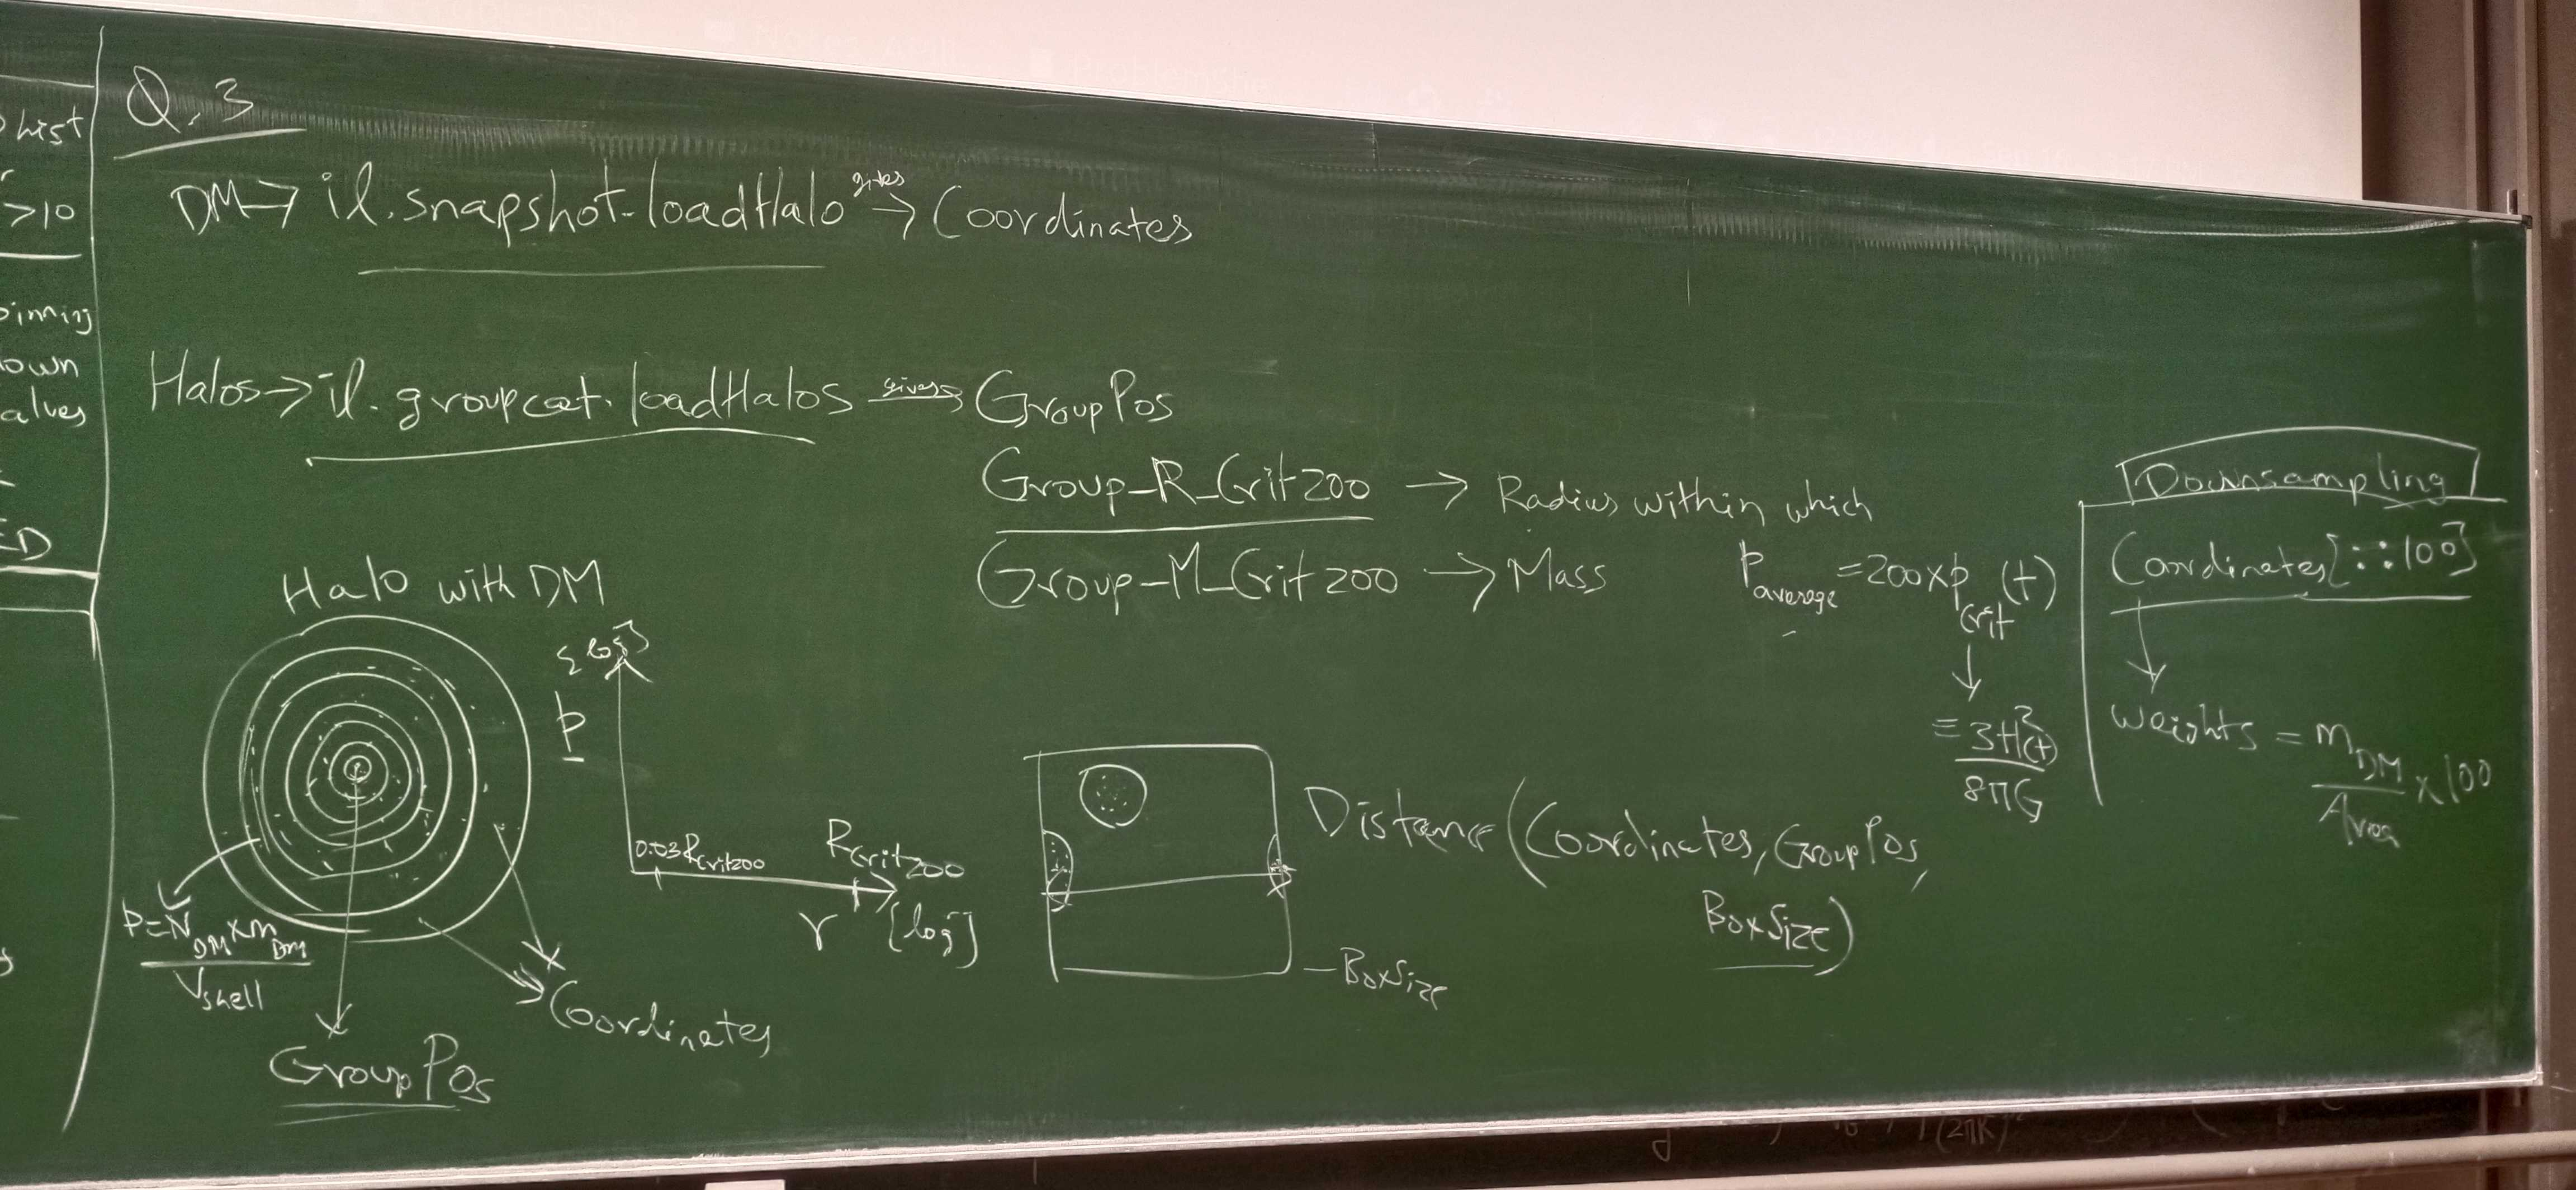

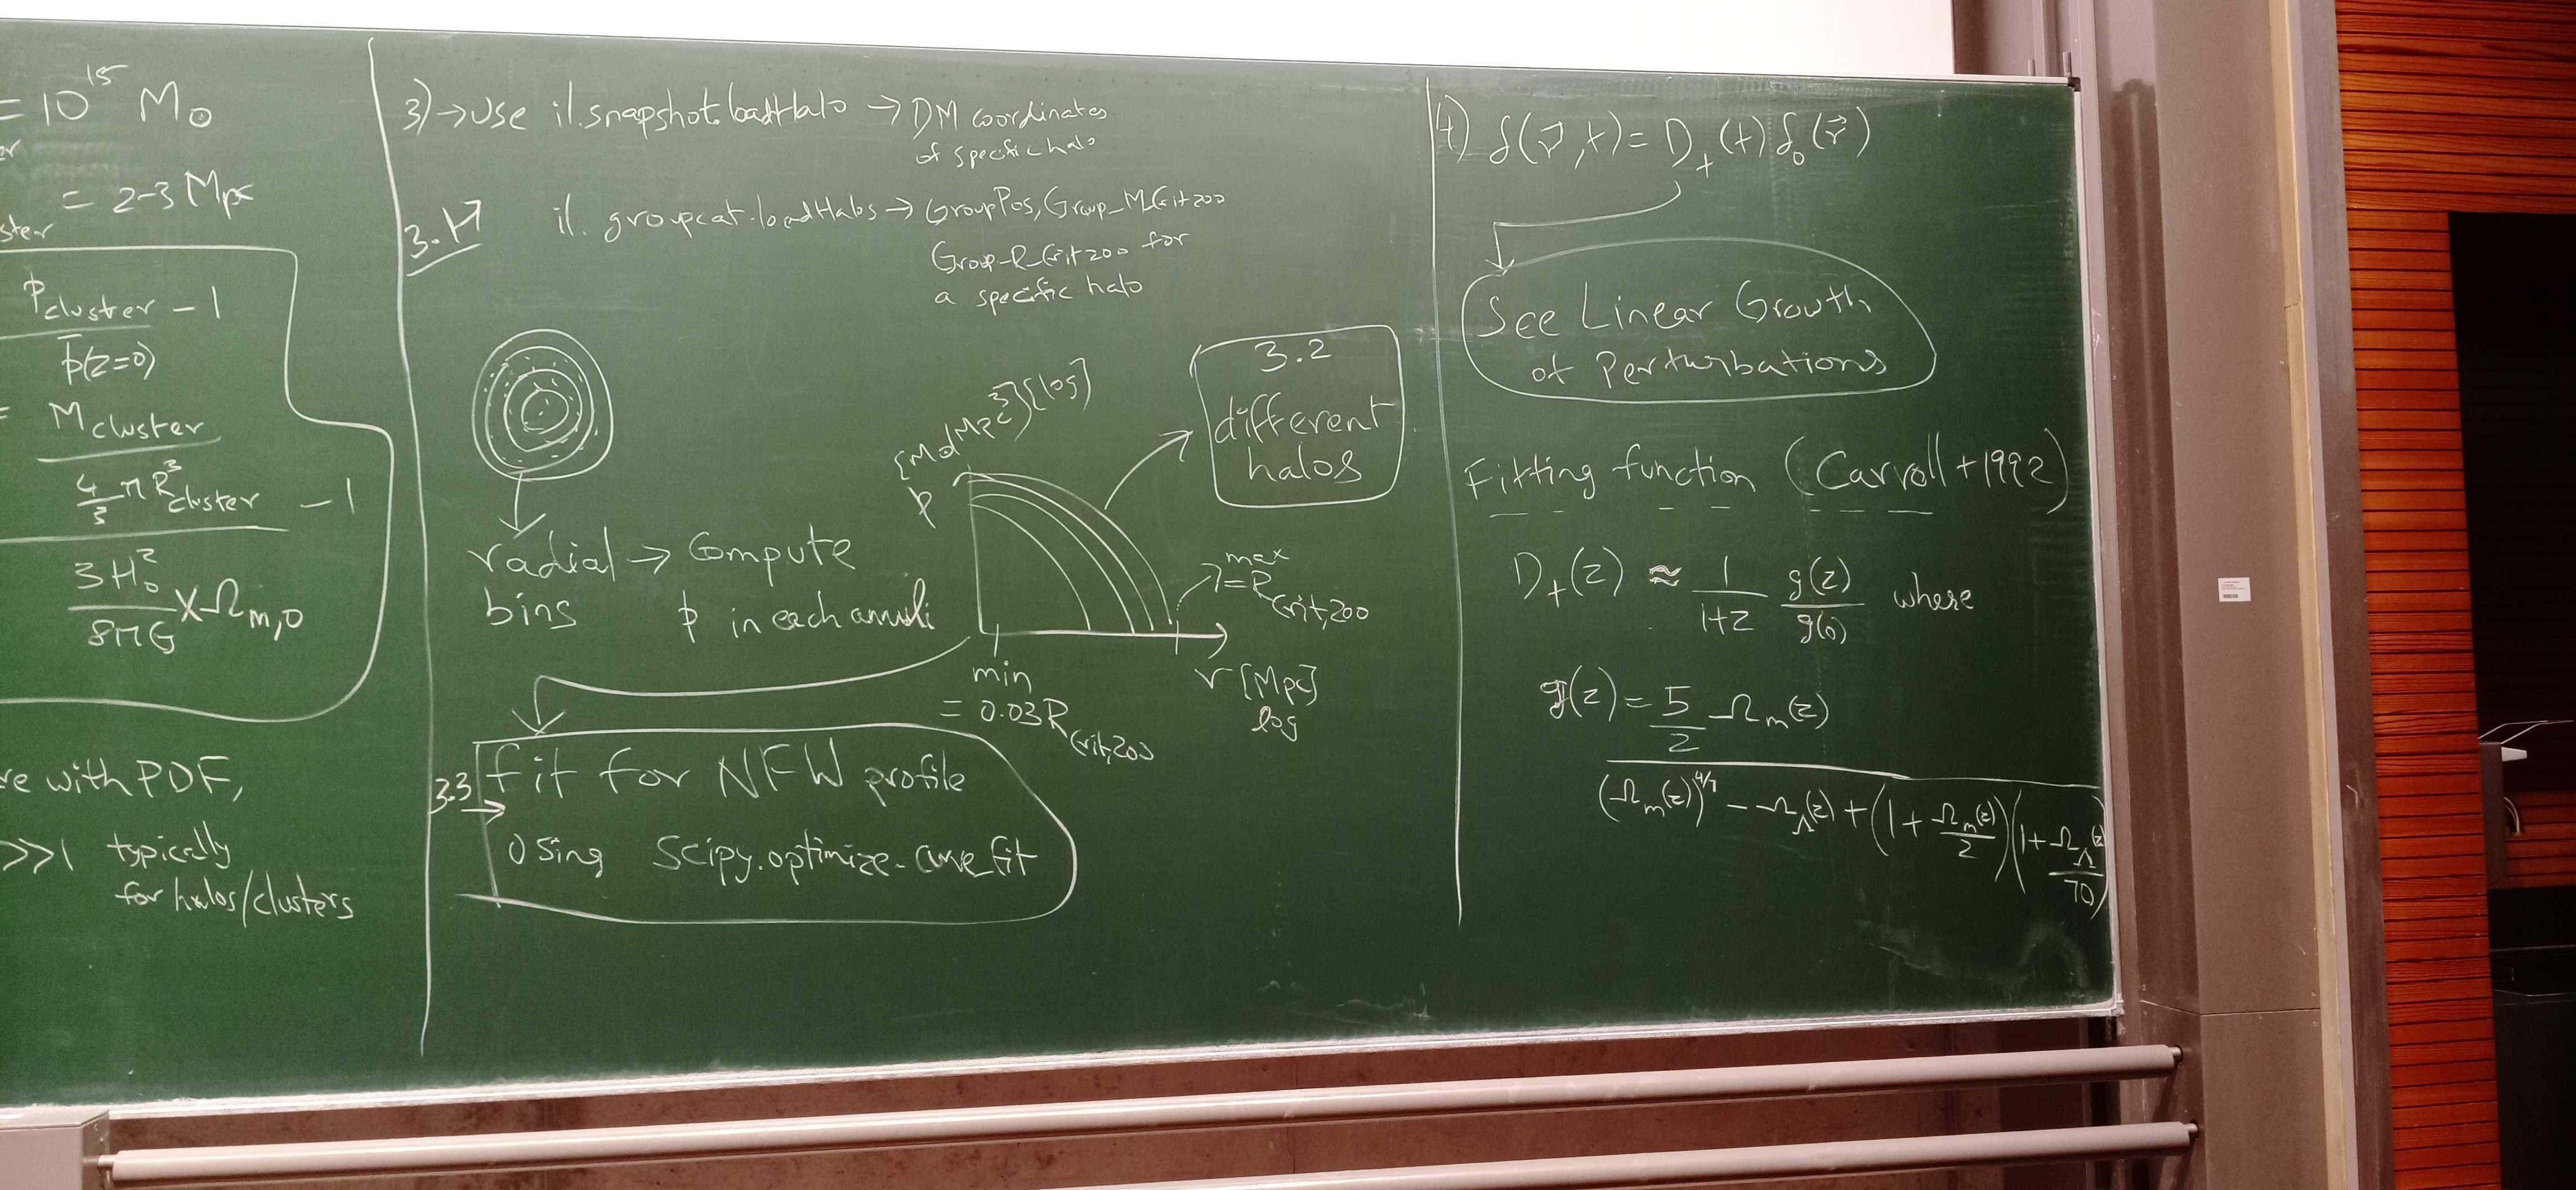

After defining a function for NFW profiles such as NFW_func, fit it for the TNG50-4-Dark density profiles using the scipy module scipy.optimize.curve_fit

In [ ]:
def NFW_func(r, rs, r200c, rho0):    #radius r, characteristic scale radius, r200_crit,characteristic density rho0
  #fill in as necessary
  return rho_r
#what are the bounds for the different parameters rs,r200c,rho0?
curve_fit(f=NFW_func,xdata=radii,ydata=densities,p0=p0=[r200c/5., r200c, rho_avg],bounds=NFW_bounds)[0]
#see https://docs.scipy.org/doc/scipy/reference/generated/scipy.optimize.curve_fit.html

# Problem Sheet 4

In this sheet, you will on one hand make halo mass functions (HMF) of numerical simulations like TNG, and also make calculations of HMF formalisms such as the Tinker HMF. For the latter, you will need to compute the matter power spectra and mass variance.

**Inputs for question 1:**

You will need to load the halo group catalogs for this (see `il.groupcat.loadHalos`), and load the fields `GroupMass, Group_M_Crit200, Group_M_Crit500, Group_M_Mean200` (see https://www.tng-project.org/data/docs/specifications/#sec2a for descriptions).

You will then use the plt.hist function to make histograms of various types (see https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.hist.html)

Arguments to use: `x, bins, weights, cumulative`

There are three kinds of halo mass functions to make - **N(>M), n=N(>M)/V, and dn/dM/dV**, i.e., **the cumulative number, cumulative number density, and differential halo mass functions**.

Hints:
  
*  For N(>M) - use `plt.hist` with `cumulative=-1` (do you know why?)

*  For n=N(>M)/V - use `plt.hist` with `cumulative=-1` and `weights = np.ones(number_of_halos)/Box_Volume` (what units should you use?)
  
*  For dn/dM/dV - `plt.hist` with `weights = np.ones(number_of_halos)/Box_Volume`

What bins should you use for the x-axis? In logspace or linear space? Make the plots for different redshifts and box sizes with the appropriate units, showing the different mass definitions together in one plot (with legend)

Make plots for all four halo mass definitions for the entirety of question 1. When quoting individual values feel free to use Group_M_Crit200

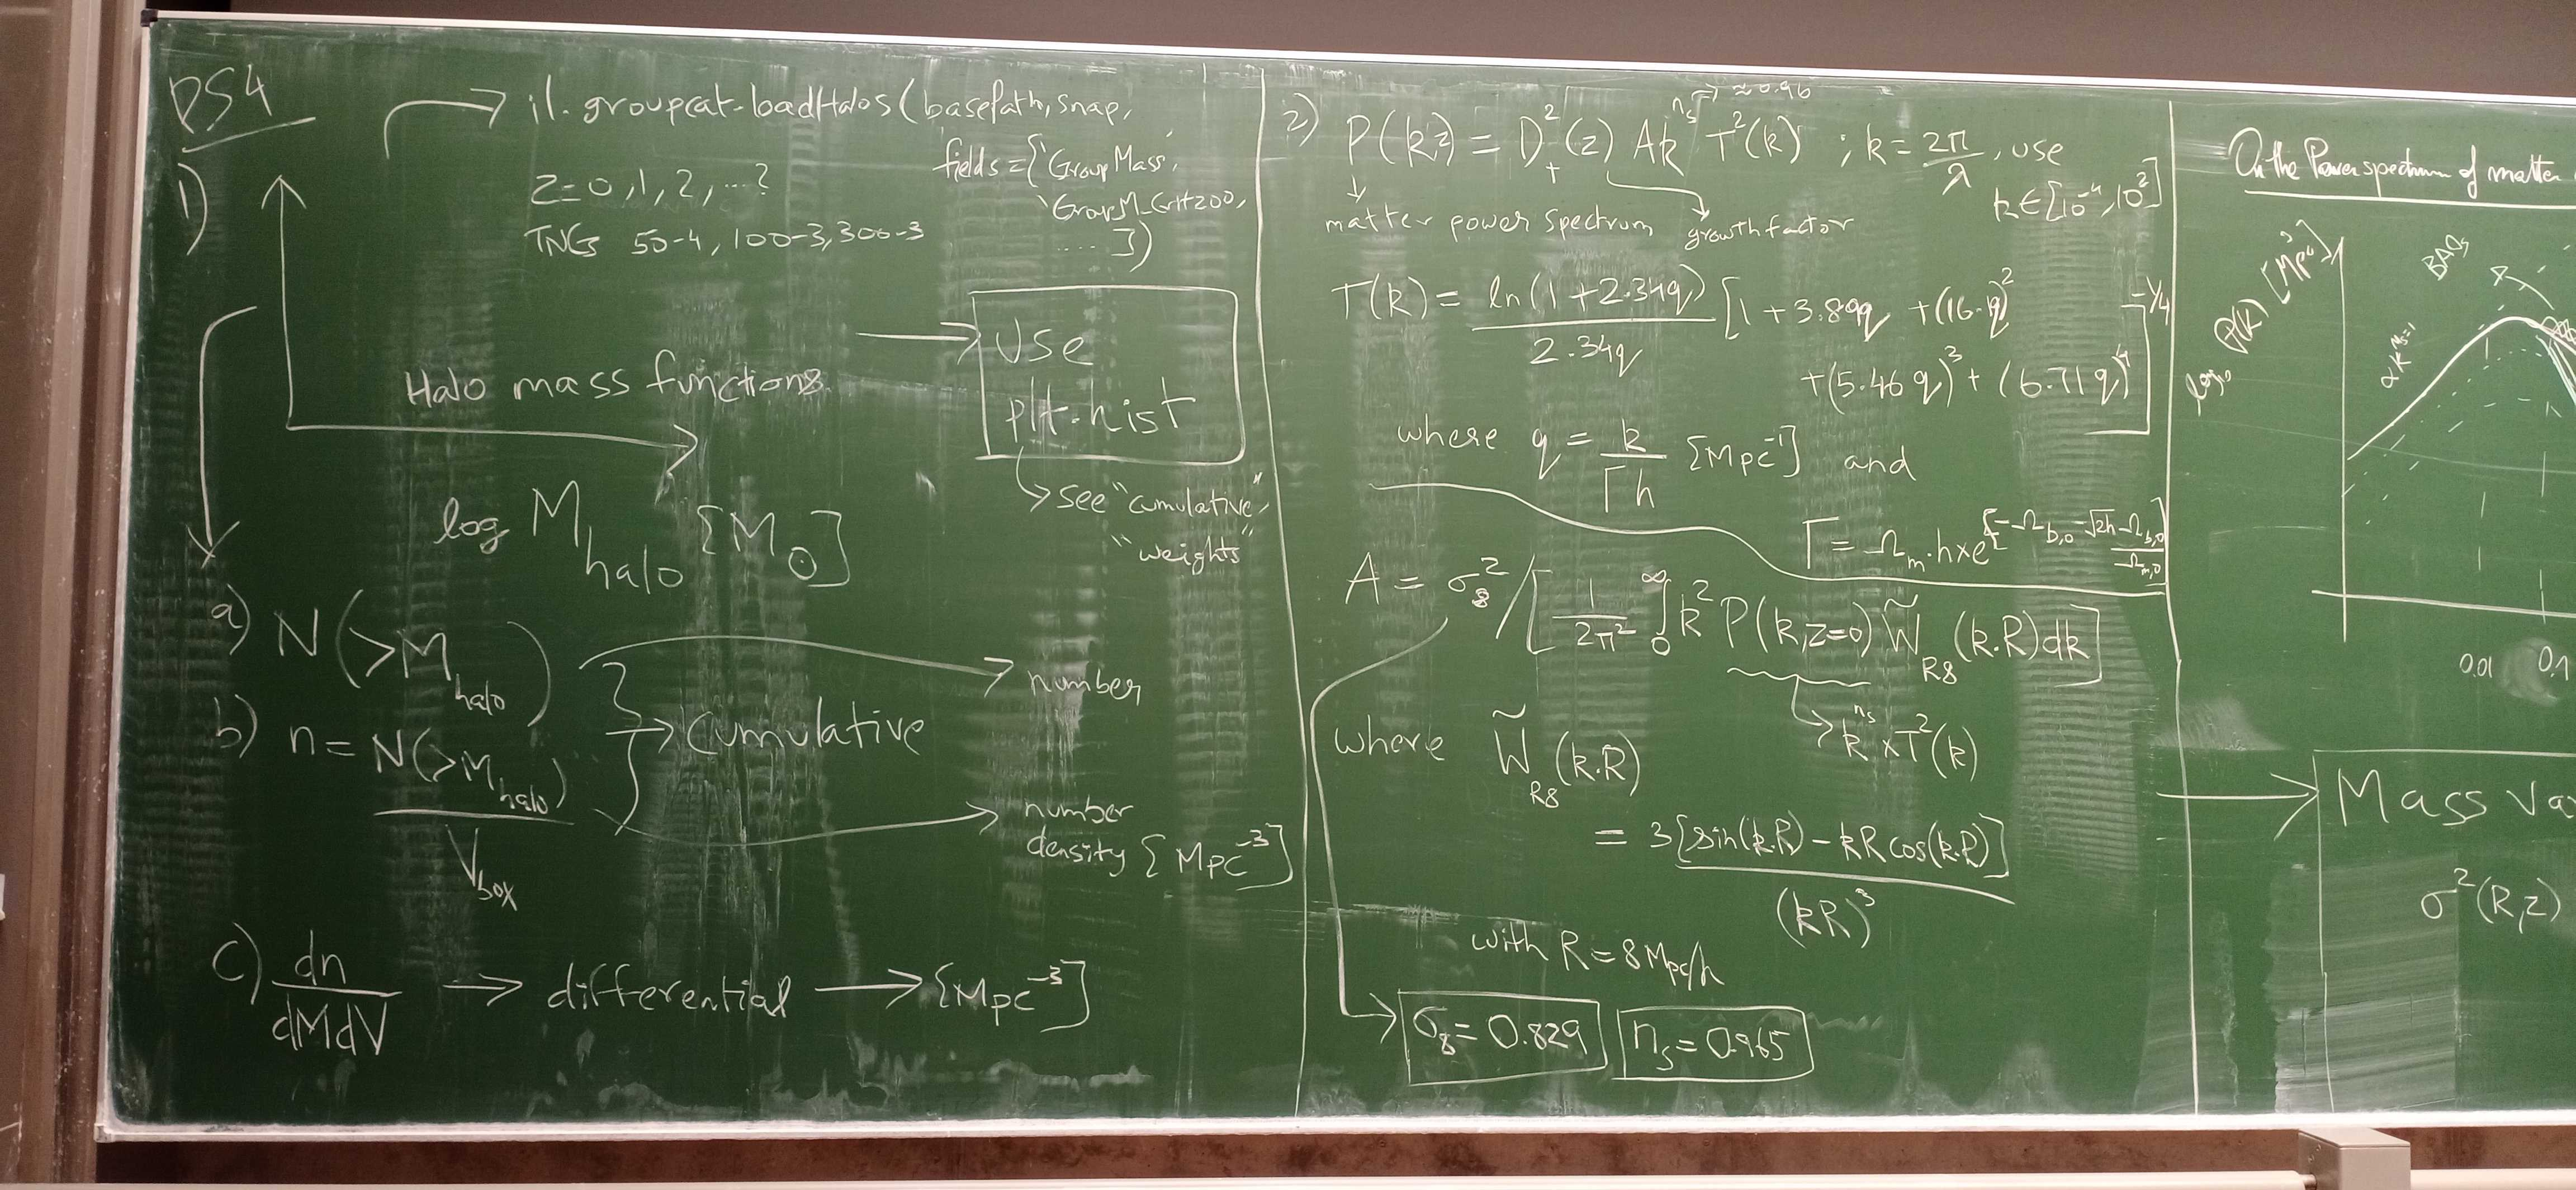

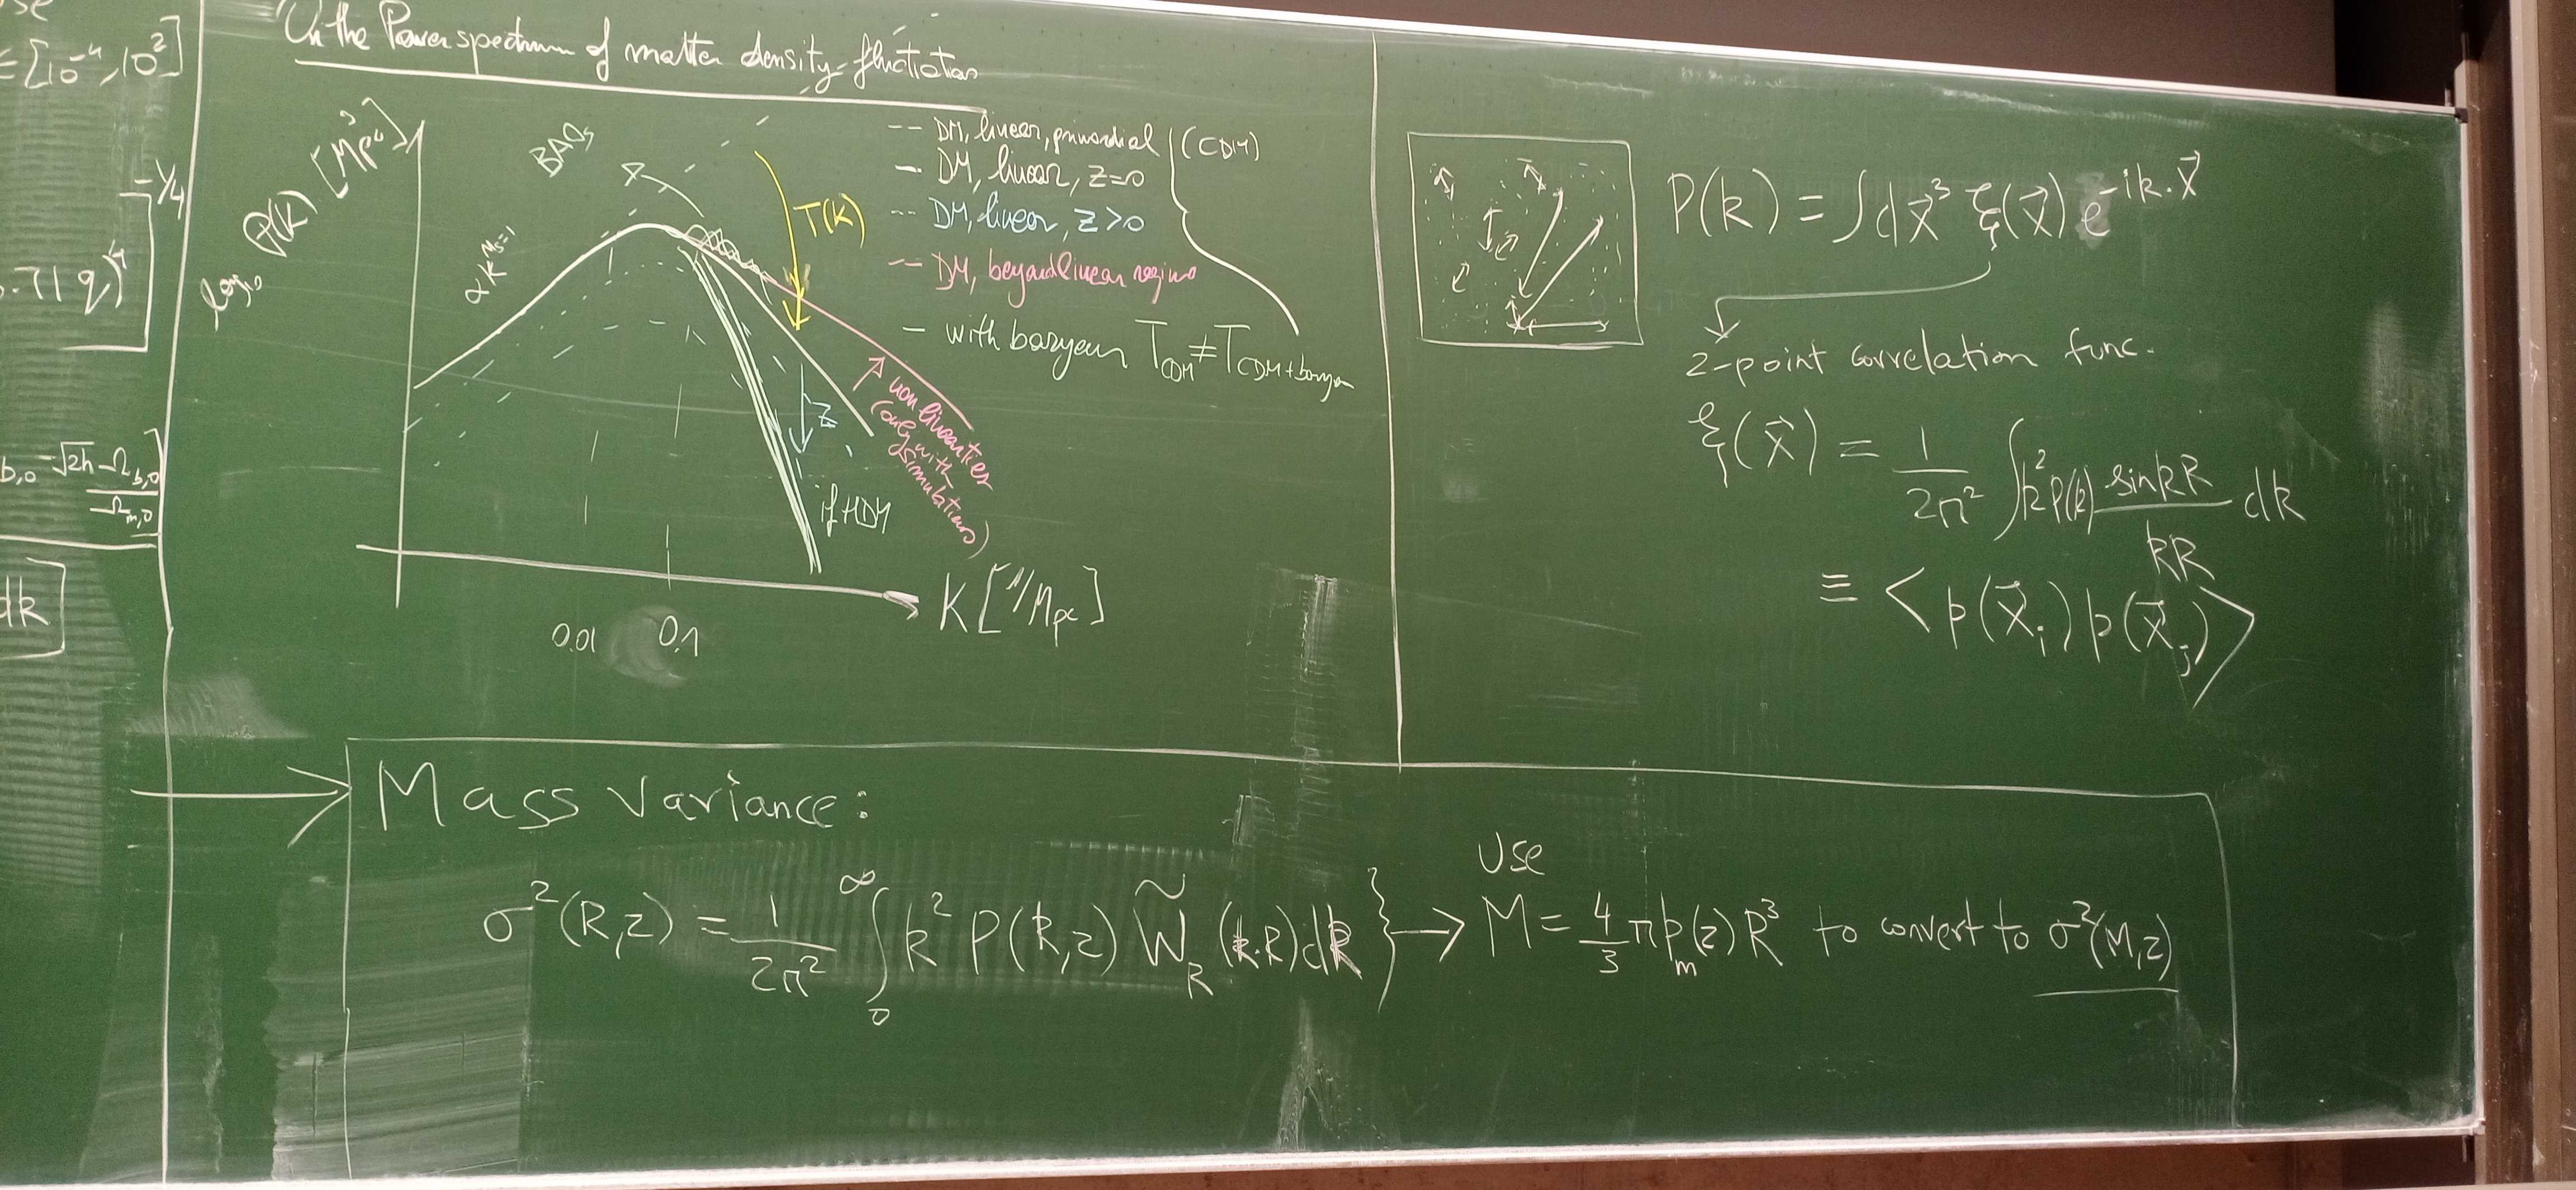

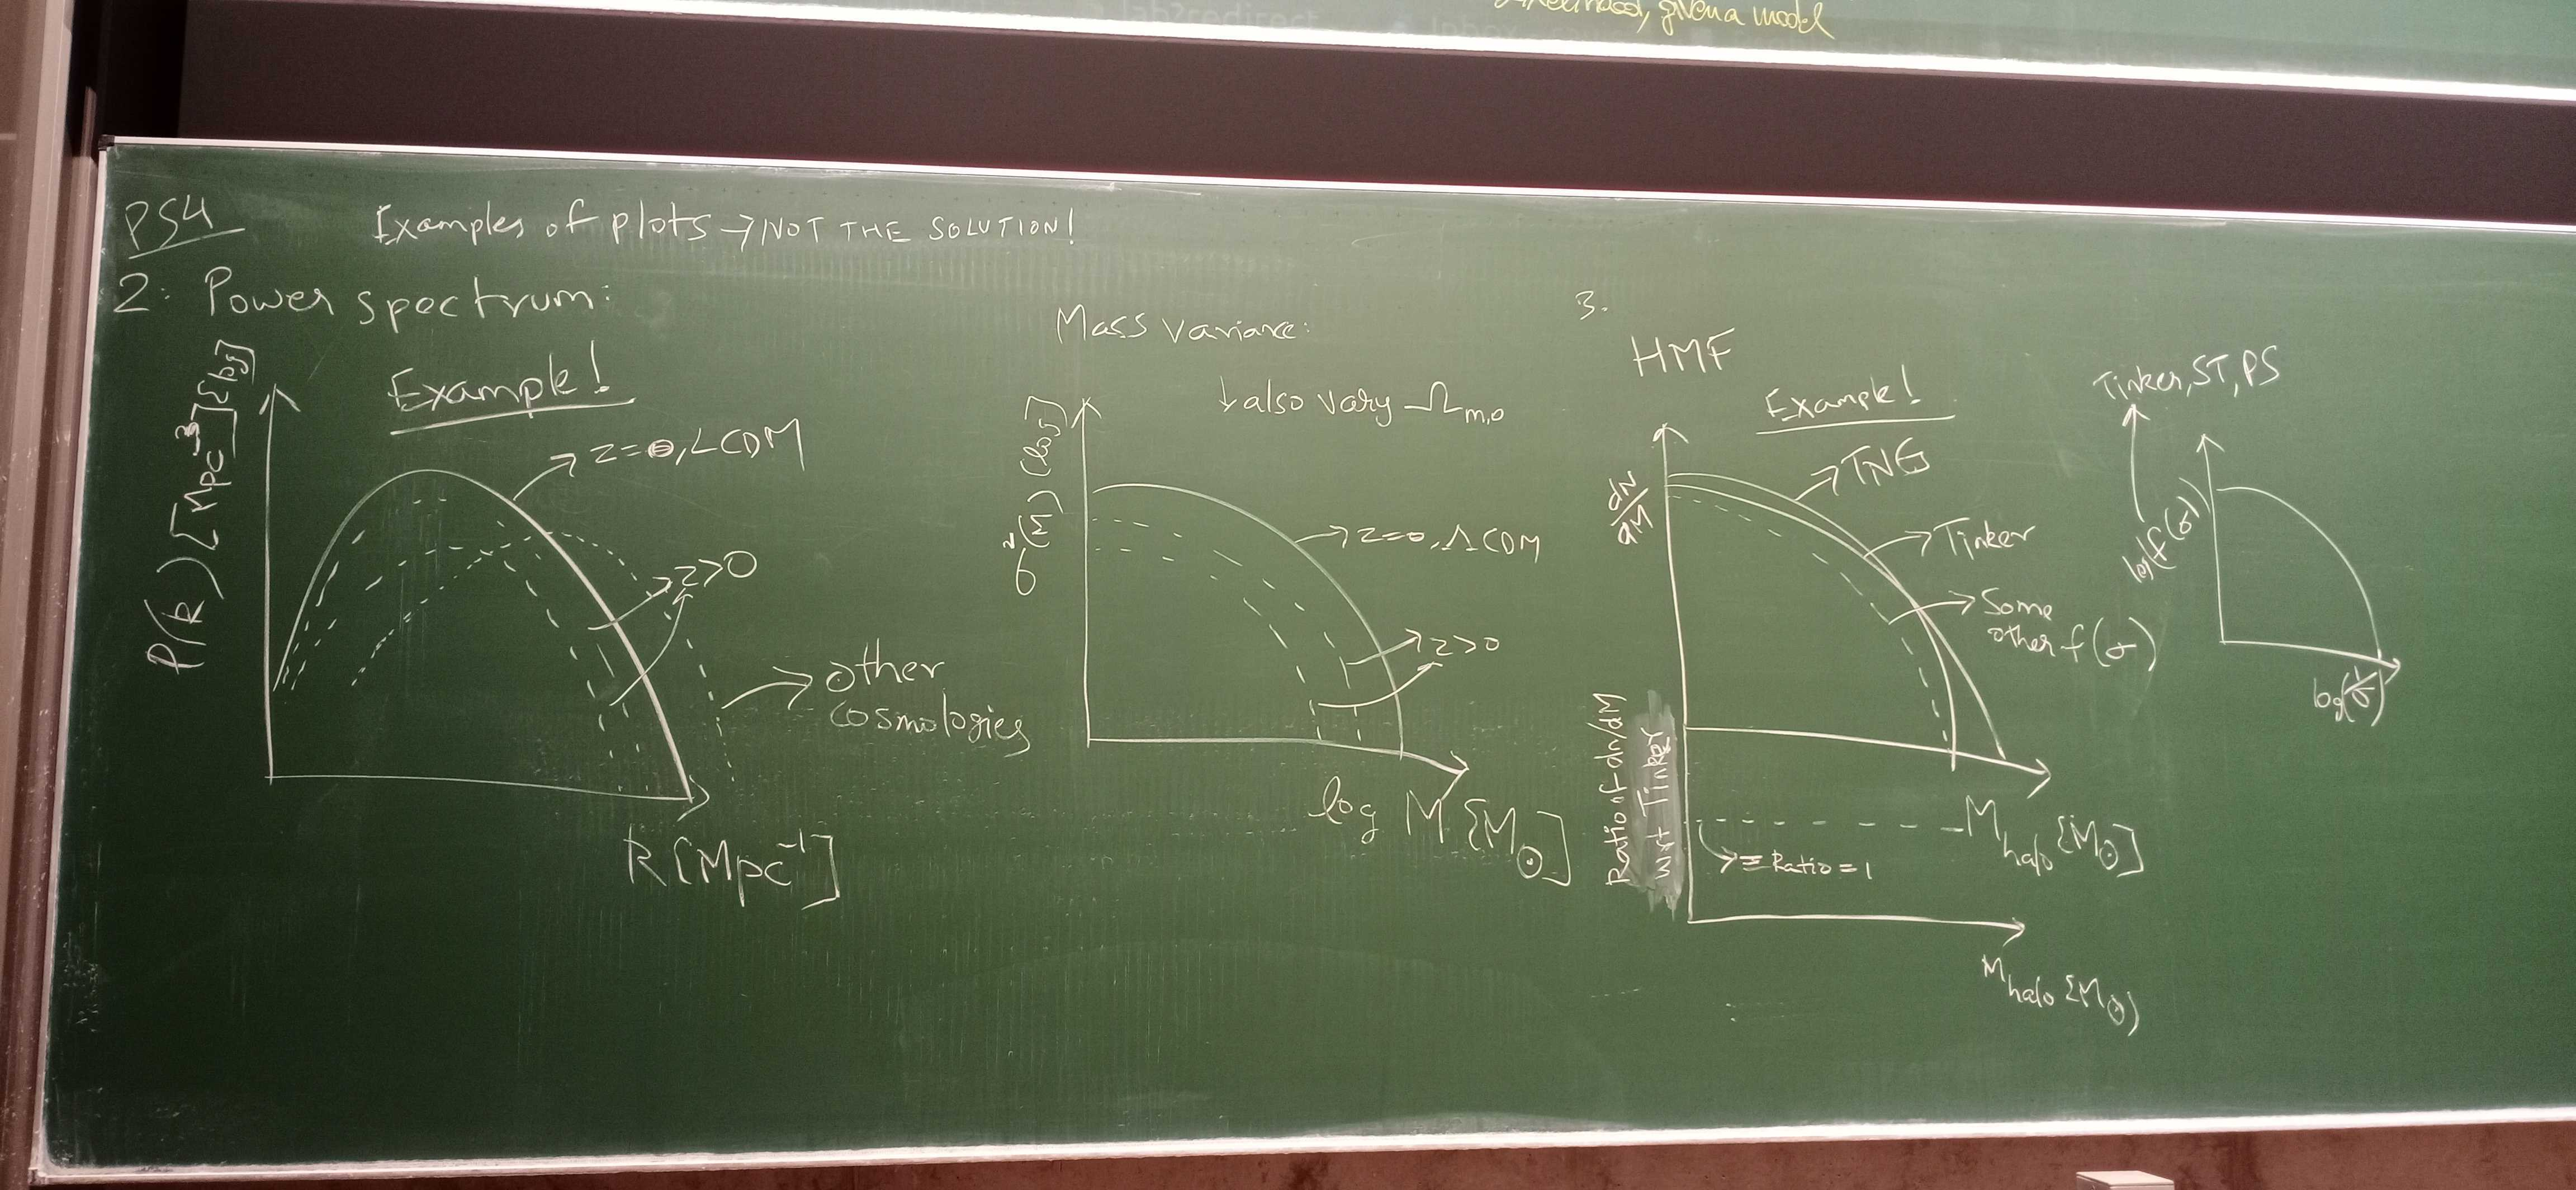

**Inputs for question 2**

Make functions for the matter power spectrum and mass variance based on the other functions you created for Problem Sheet 2. Use a range of k values as $[10^{-4},10^{2}]$ in log space for your plots. See the functions mentioned above for the analytical equations - note that you will have to perform integrations using scipy.intergrate.quad again!

Once you've made your functions, make a plot of P$(k)$ vs $k$ for different redshifts. Then $\sigma(M,z)$ vs $M$ for different refshifts: for $M$, use a range of $[10^{10}-10^{16}]\,M_\odot$ - NOTE THAT THE MASS VARIANCE EQUATION IS SLIGHTLY WRONG, THE WINDOW FUNCTION SHOULD BE SQUARED!!!

**Inputs for question 3**

Compute the differential halo mass function from the mass variance:

$\frac{dn}{dM}(M,z)=f(\sigma)\frac{\rho_M}{M}\frac{d\mathrm{ln}[\sigma^{-1}(M,z)]}{dM}$ where $f(\sigma)$ is defined for Tinker+2008, Press-Schechter 1974, and Sheth-Tormen 1999 separately (see class notes). Here $\sigma$ is the mass variance as a function of redshift and mass $M$ which you can take numerically within a range same as the previous question.

You will need to perform numerical differentiation, as the RHS of the equation above has a derivative wrt $M$. Use `numpy.gradient` for this!

You can find the tinker parameter values to compute $f(\sigma)$ from the paper below: use $\Delta=200$ (feel free to try other overdensity values too!)

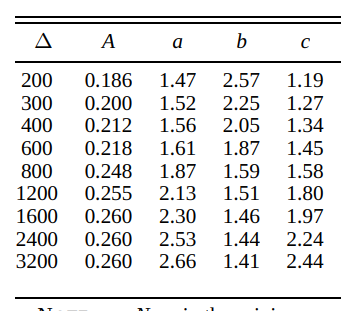

# Problem Sheet 5

Use the inputs on the board to solve the problems

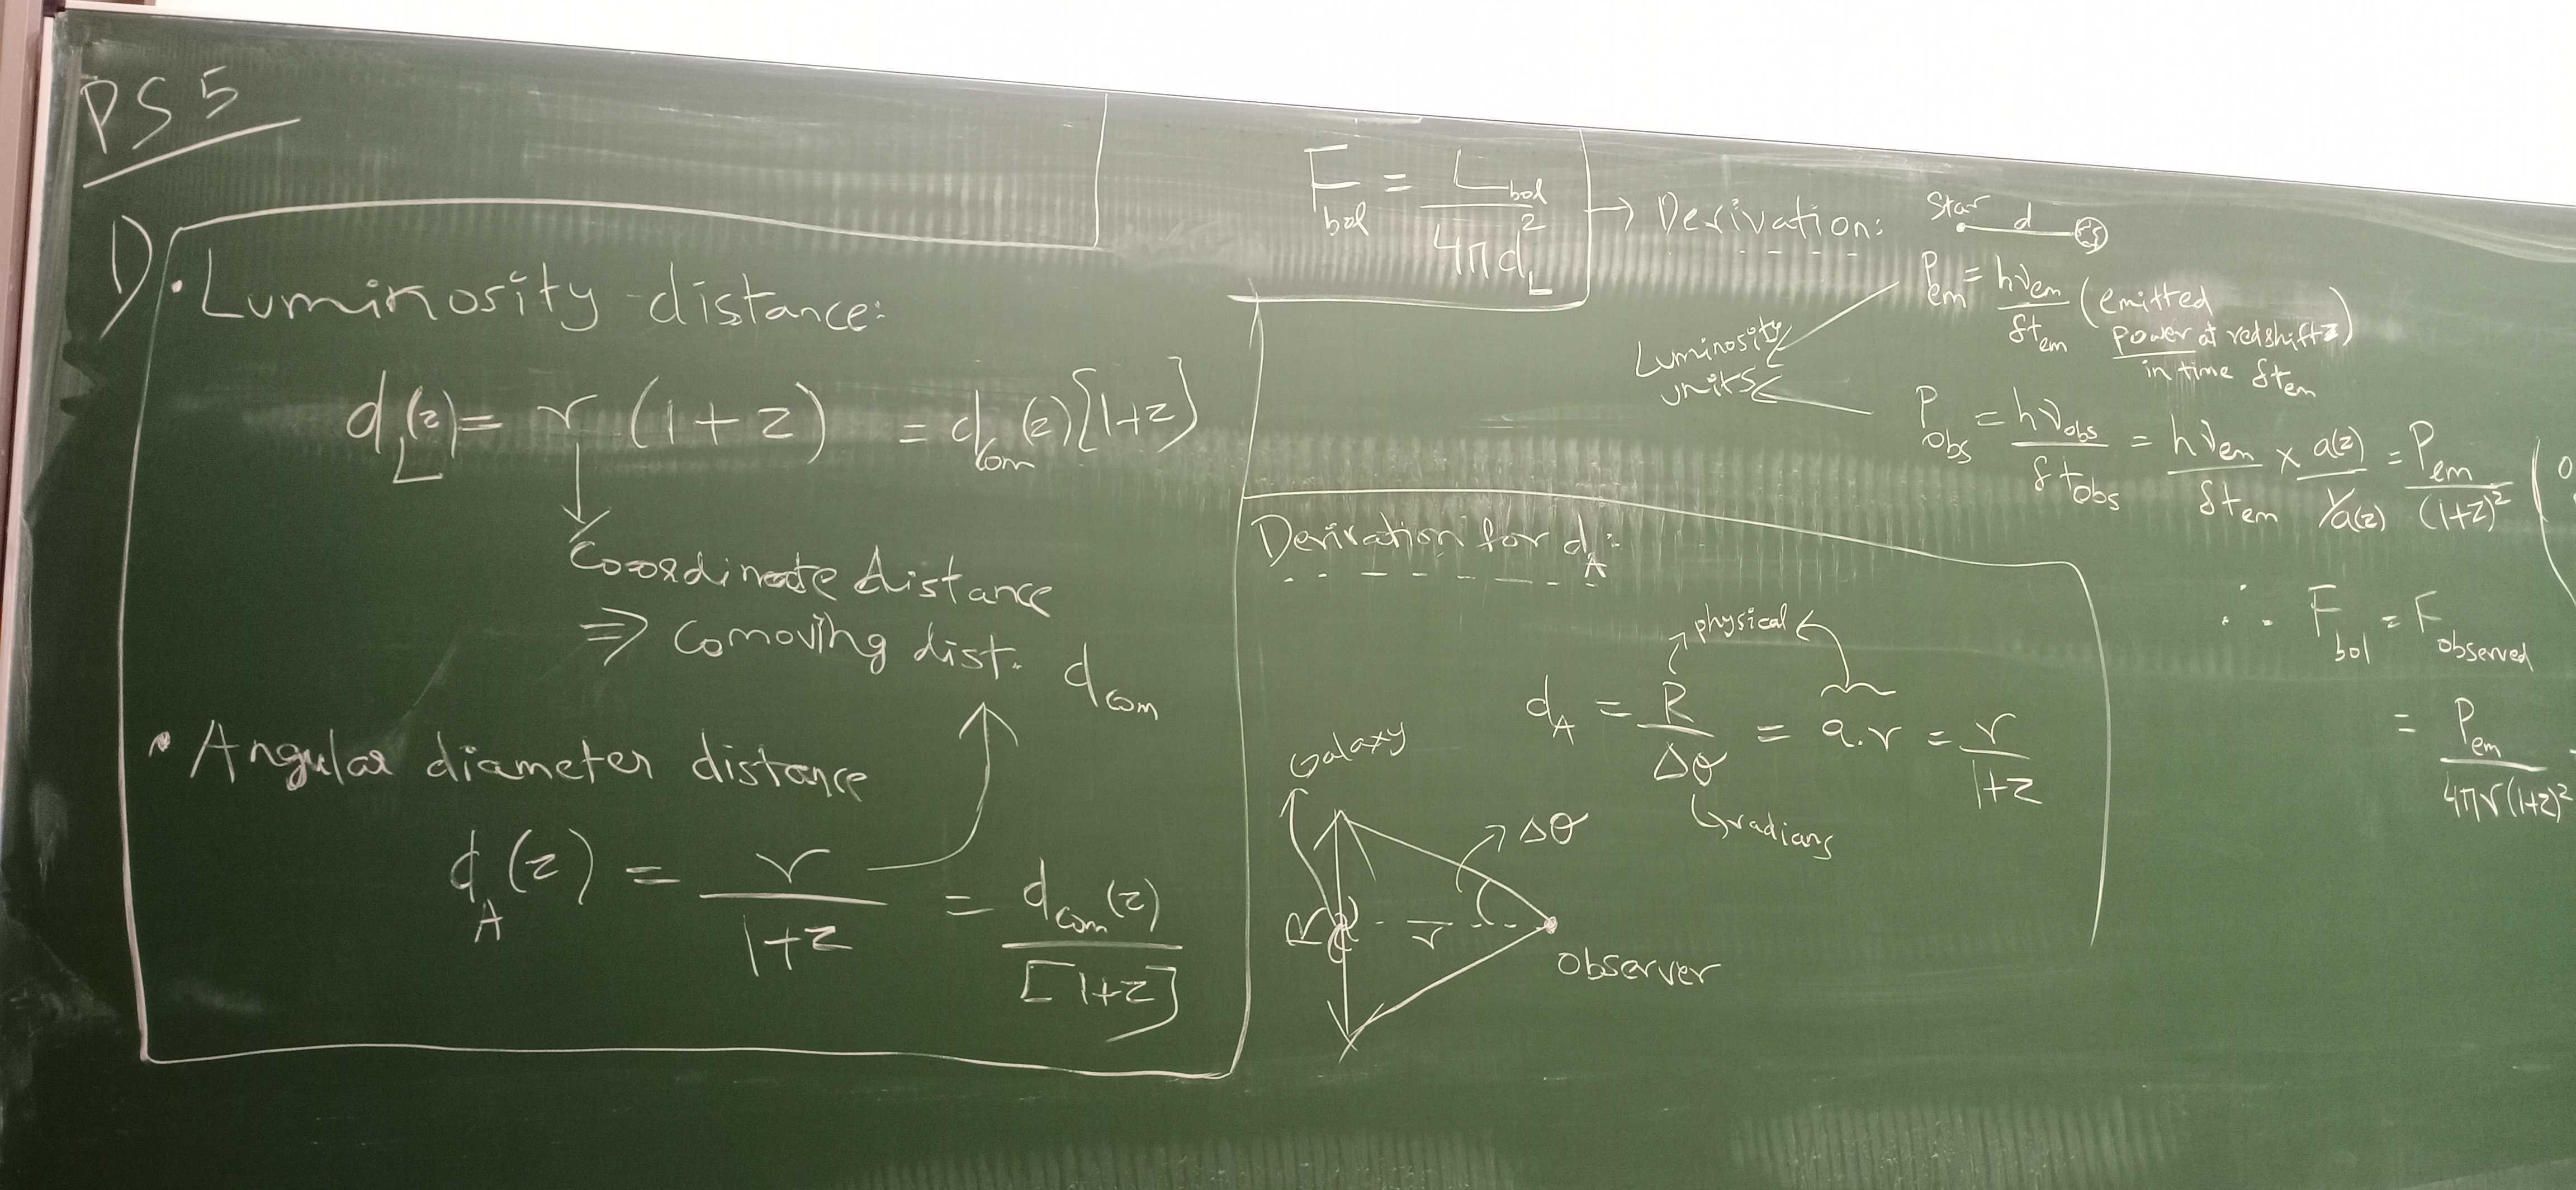

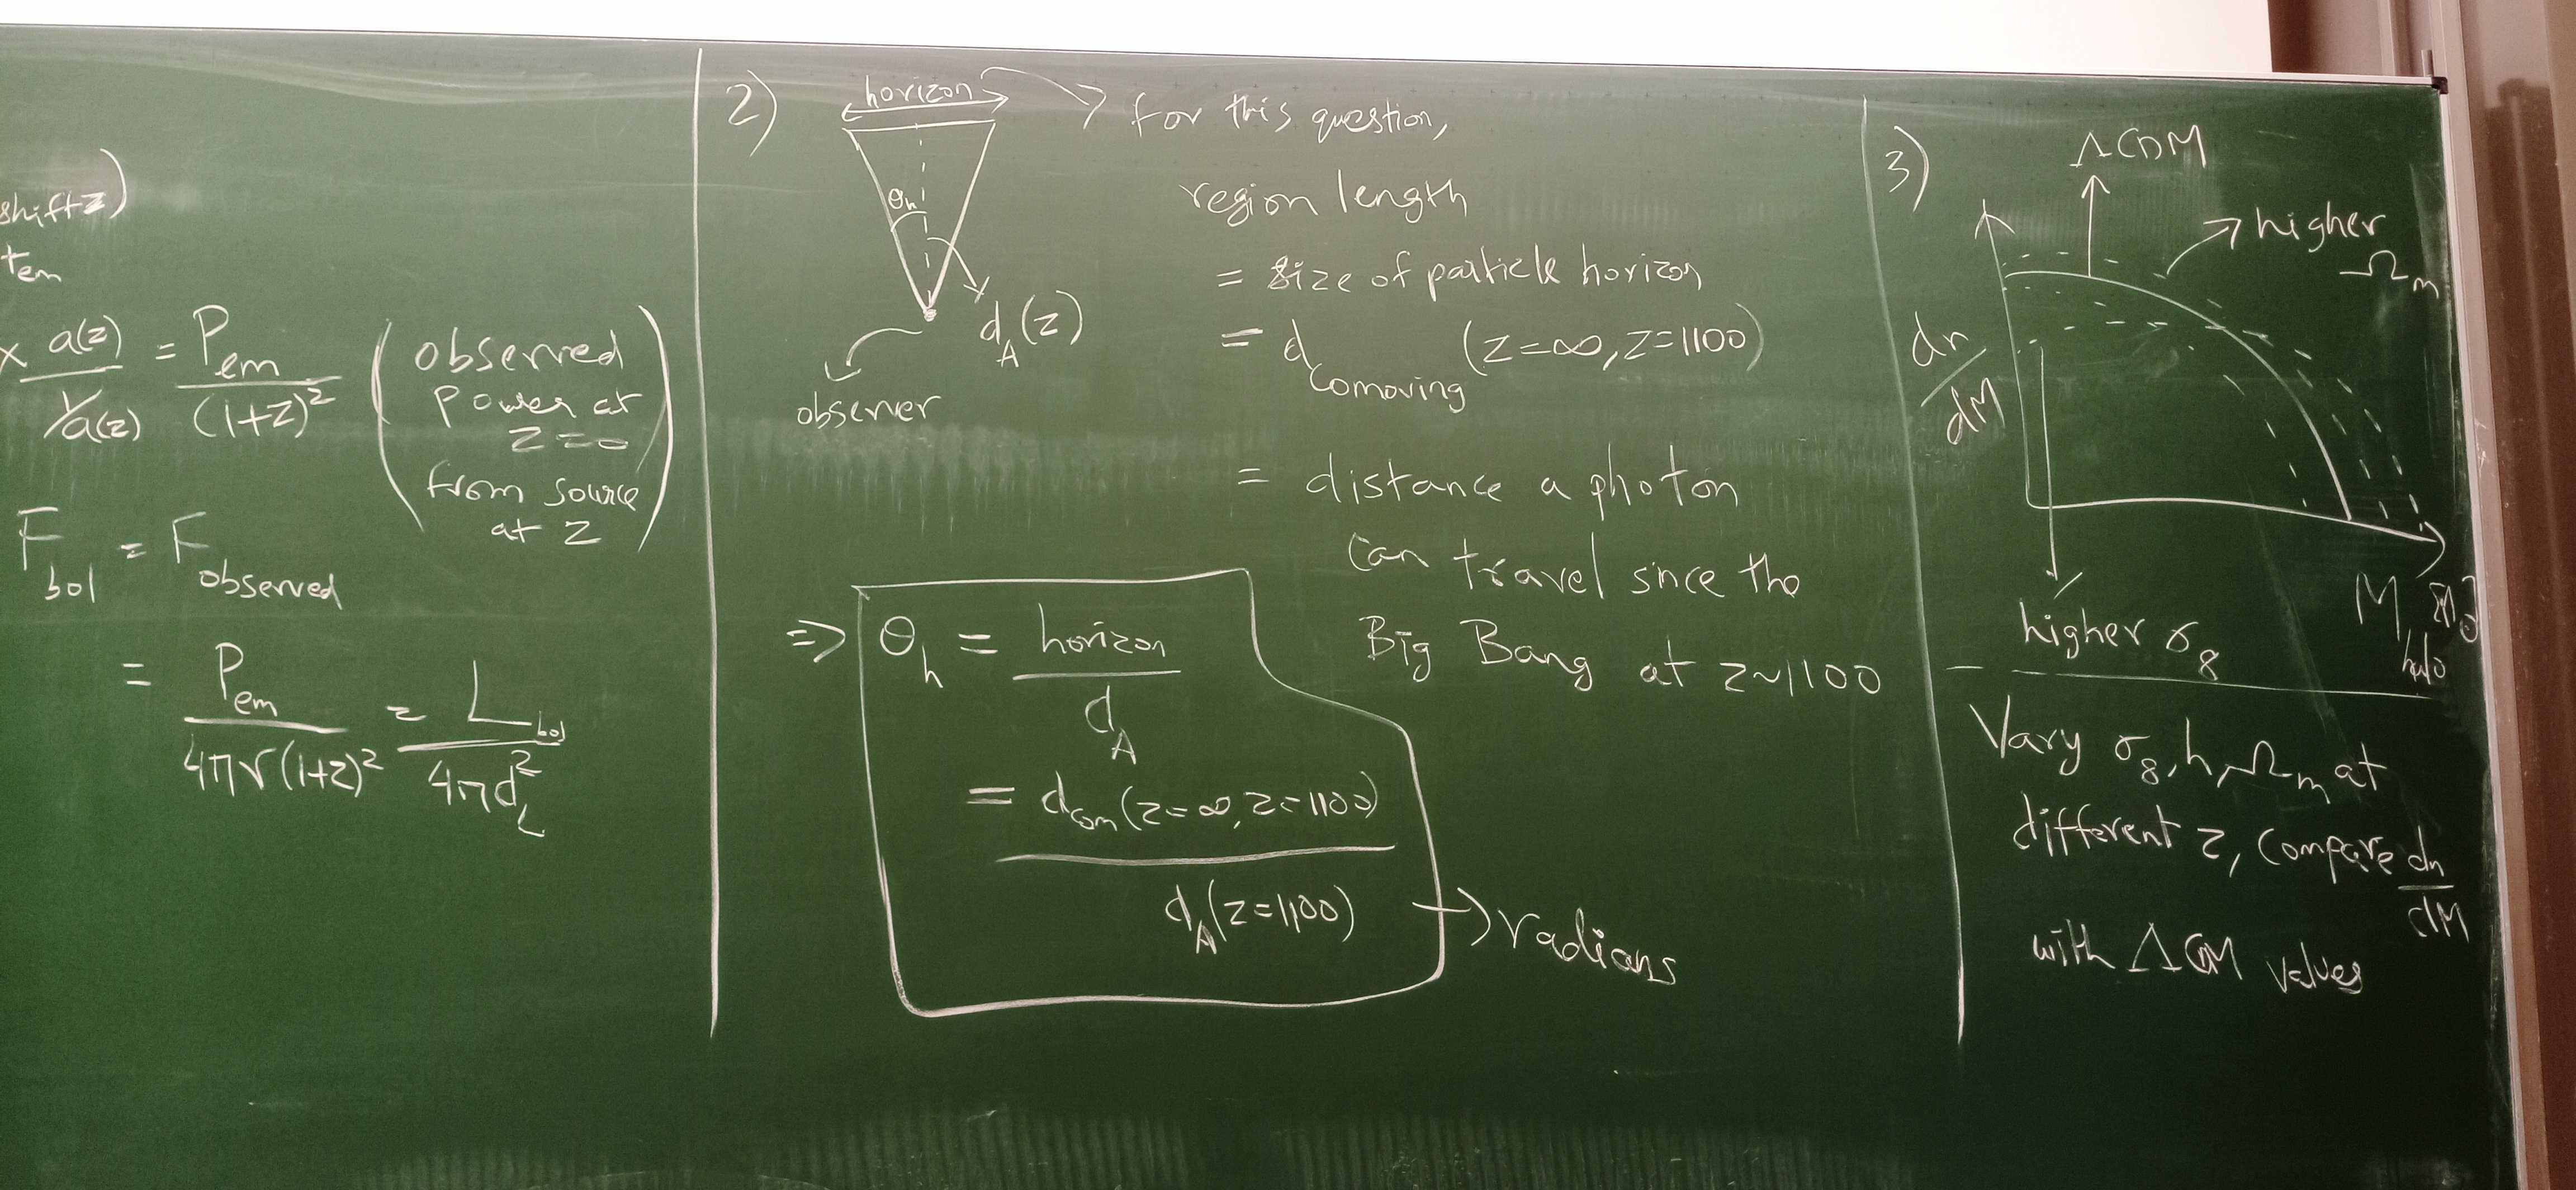

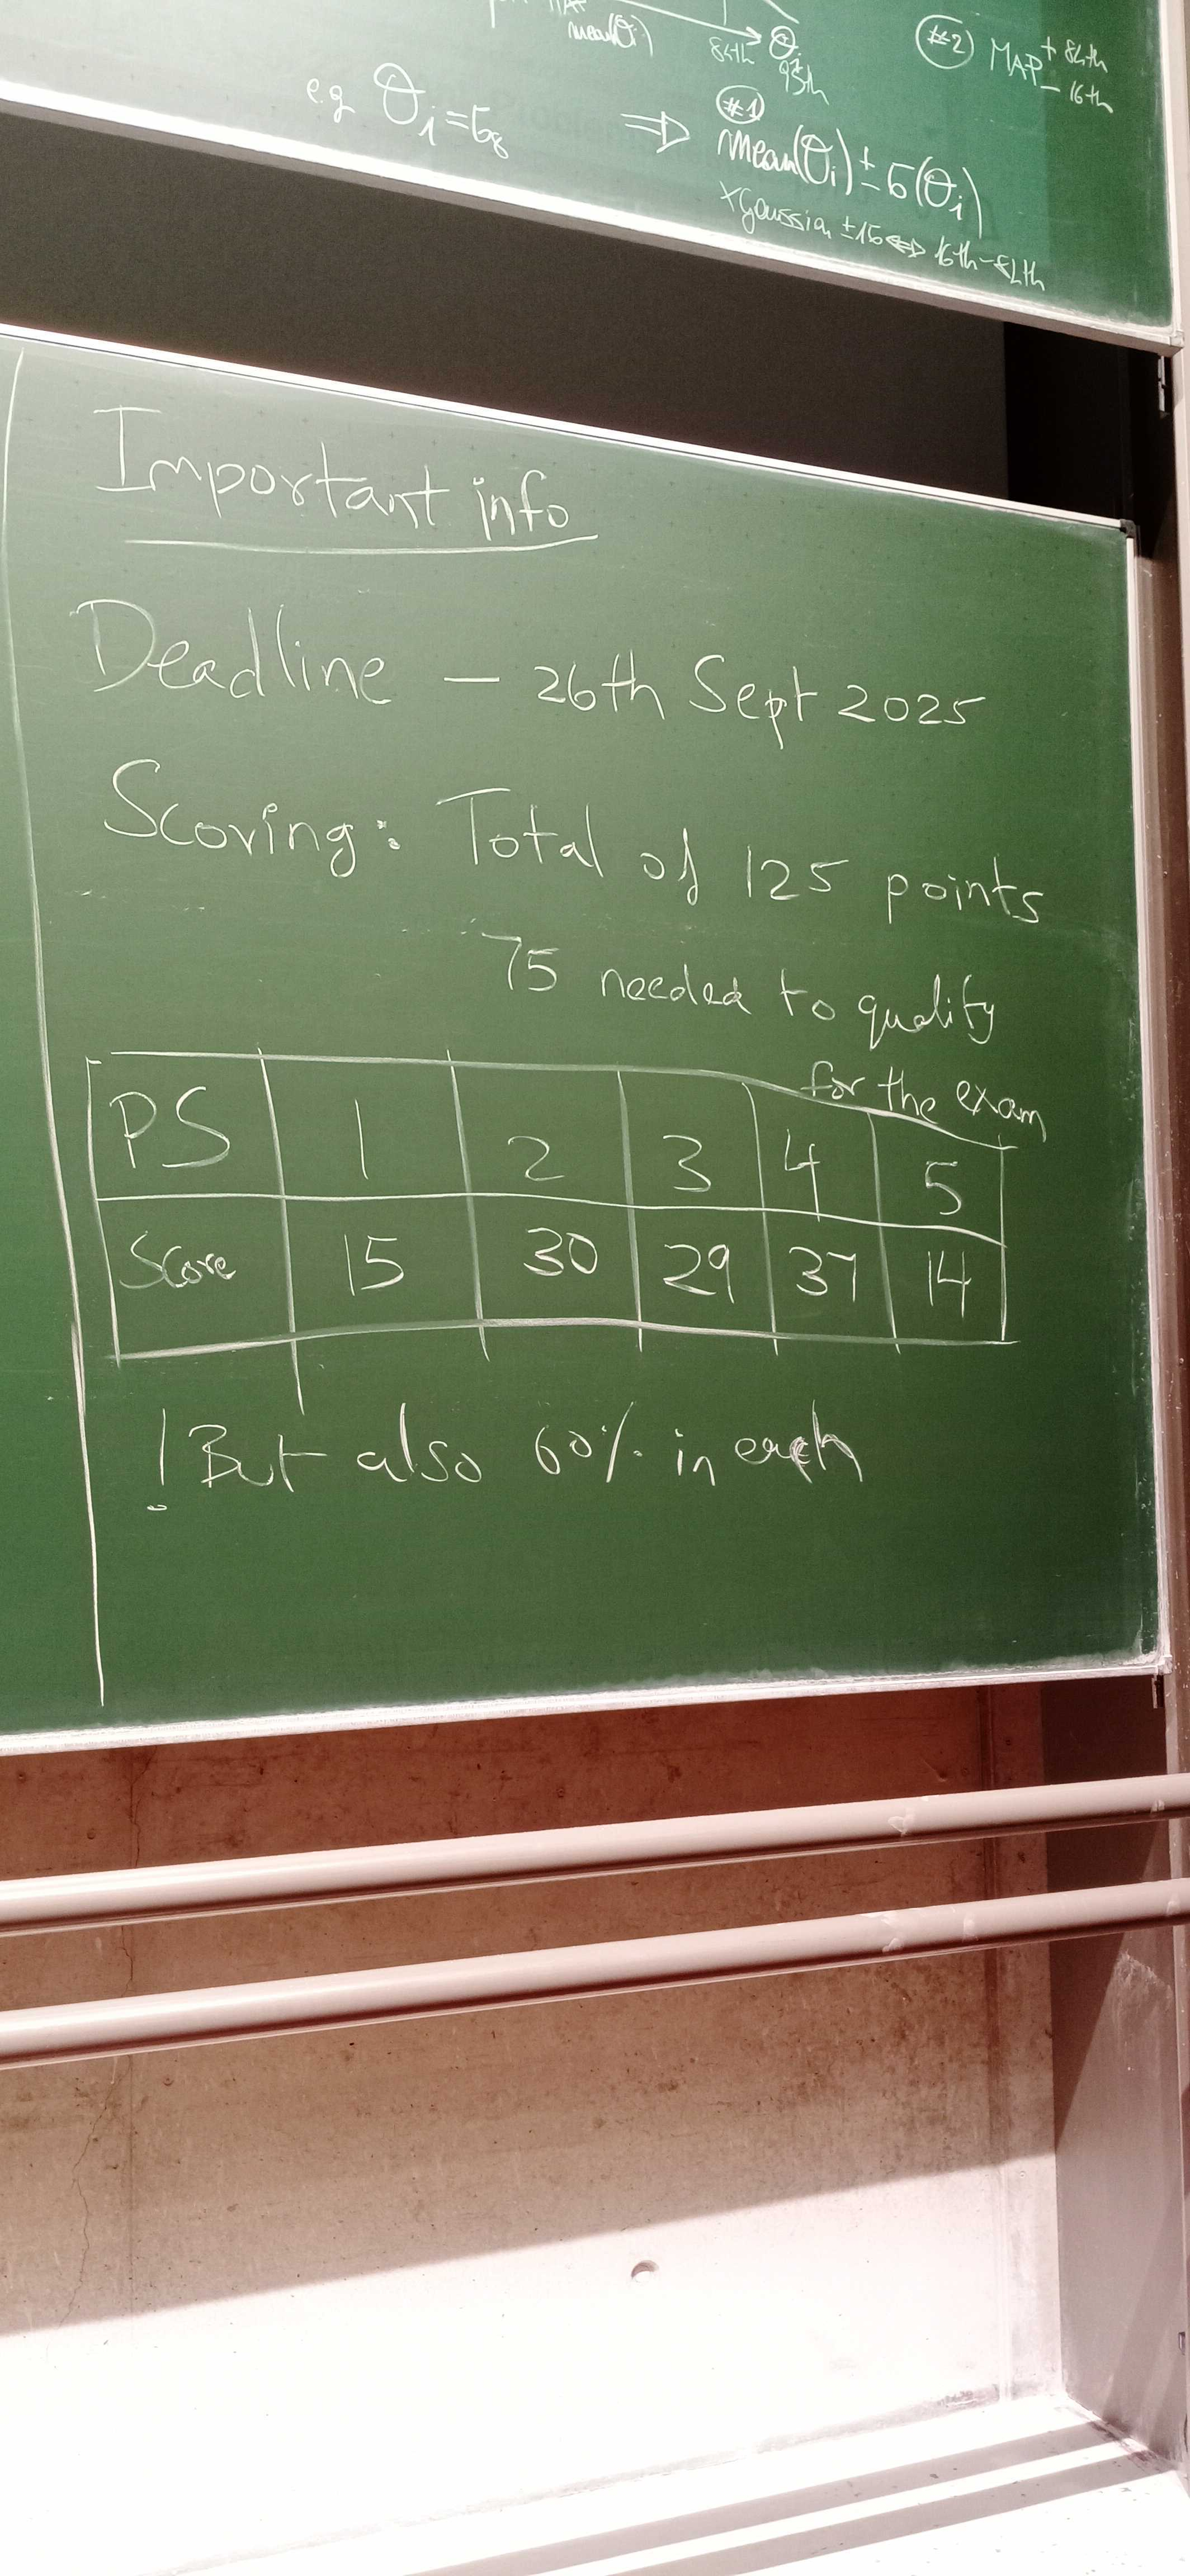